In [1]:
import os
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Proiect_Licenta_XAUUSD'
processed_data_path = os.path.join(PROJECT_PATH, 'data/processed/XAUUSD_with_indicators.csv')

df_final = pd.read_csv(processed_data_path, index_col=0, parse_dates=True)

print(f"Data has been successfully loaded! Rows: {len(df_final)}")
display(df_final.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data has been successfully loaded! Rows: 124688


,open,high,low,close,volume,ema_50,ema_200,dist_ema_200,atr,bb_lower,...,is_vix_green,smi_10_20_5_1_0,smis_10_20_5_1_0,smio_10_20_5_1_0,smi_oversold,smi_overbought,ret_1h,ret_3h,hour,day_of_week
date,,,,,,,,,,,,,,,,,,,,,
2004-06-24 05:00:00,393.6,394.1,393.6,393.6,37,393.931518,388.806500,0.012329,1.010181,392.972963,...,0,-0.069261,-0.039687,-0.029574,0,0,0.000000,0.000000,5,3
2004-06-24 06:00:00,393.8,394.1,393.6,393.6,37,393.918518,388.854197,0.012205,0.973739,392.936717,...,0,-0.080793,-0.053389,-0.027404,0,0,0.000000,0.000000,6,3
2004-06-24 07:00:00,393.6,394.3,393.6,393.8,44,393.913870,388.903408,0.012591,0.954187,392.946133,...,0,-0.081352,-0.062710,-0.018641,0,0,0.000508,0.000508,7,3


In [2]:
# Horizont of prediction (3 HOURS)
prediction_horizon = 3

# Target variable :  Percentage return over 3 hours
df_model = df_final.copy()
df_model['target'] = (df_model['close'].shift(-prediction_horizon) / df_model['close']) - 1

df_model = df_model.dropna()

features = [
    'dist_ema_200', 'atr', 'bb_pct', 'fix_vix', 'is_vix_green', 
    'smi_oversold', 'smi_overbought', 'ret_1h', 'ret_3h', 'hour', 'day_of_week'
]

smi_col = [c for c in df_model.columns if 'smi' in c and 'over' not in c and '_s' not in c][0]
features.append(smi_col)

X = df_model[features]
y = df_model['target']


split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"We train on data to: {X_train.index[-1]}")
print(f"We test on data from: {X_test.index[0]}")

We train on data to: 2021-09-10 23:00:00
We test on data from: 2021-09-13 01:00:00


Training started on the full set
------------------------------
BASELINE RESULTS (Random Forest):
Root Mean Squared Error (RMSE): 0.004133
Mean Absolute Error (MAE): 0.002386
R2 Score: -0.217286
------------------------------


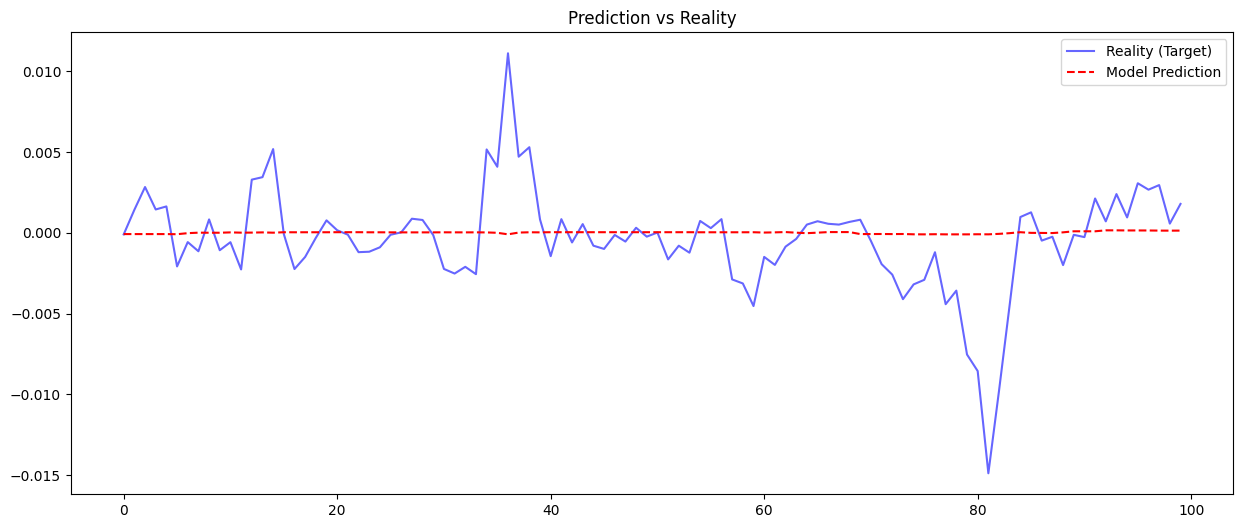

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt


model_rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)

print("Training started on the full set")

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"BASELINE RESULTS (Random Forest):")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R2 Score: {r2:.6f}")
print("-" * 30)


plt.figure(figsize=(15, 6))
plt.plot(y_test.values[:100], label='Reality (Target)', color='blue', alpha=0.6)
plt.plot(y_pred[:100], label='Model Prediction', color='red', linestyle='--')
plt.title('Prediction vs Reality')
plt.legend()
plt.show()

In [4]:

print(f"Infinite values: {np.isinf(X_train).values.sum()}")
print(f"Missing values: {X_train.isnull().sum().sum()}")


correlations = df_model[features + ['target']].corr()['target'].sort_values(ascending=False)
print("\n Indicators correlation with the Target:")
print(correlations)

Infinite values: 0
Missing values: 0

 Indicators correlation with the Target:
target             1.000000
day_of_week        0.023424
smi_10_20_5_1_0    0.015269
bb_pct             0.011976
hour               0.011137
is_vix_green       0.002285
smi_overbought     0.000793
dist_ema_200      -0.001692
smi_oversold      -0.002883
atr               -0.005086
ret_1h            -0.007181
ret_3h            -0.008771
fix_vix           -0.012791
Name: target, dtype: float64


In [5]:
import joblib

model_save_path = os.path.join(PROJECT_PATH, 'models/random_forest_v1.pkl')
joblib.dump(model_rf, model_save_path)

print(f"The Baseline model has been saved in: {model_save_path}")

The Baseline model has been saved in: /content/drive/MyDrive/Proiect_Licenta_XAUUSD/models/random_forest_v1.pkl


In [6]:
results_baseline = {
    'Model': 'Random Forest (Baseline)',
    'RMSE': rmse,
    'MAE': mae,
    'R2 Score': r2
}

df_results = pd.DataFrame([results_baseline])

results_path = os.path.join(PROJECT_PATH, 'data/processed/model_comparison.csv')
df_results.to_csv(results_path, index=False)

print("The results were stored for final comparison.")
display(df_results)

The results were stored for final comparison.


,Model,RMSE,MAE,R2 Score
0,Random Forest (Baseline),0.004133,0.002386,-0.217286
